# Detekcja naczyń krwionośnych dna oka (CHASE_DB1)
## Blood-vessel segmentation in retinal fundus images

Autorska aplikacja w Jupyter Notebook, która dla **każdego piksela** obrazu dna oka
decyduje, czy należy on do **naczynia krwionośnego** (klasa pozytywna), czy do **tła**
(klasa negatywna) — klasyfikacja binarna.

Projekt realizuje **trzy metody** na jednej, wspólnej bazie obrazów **CHASE_DB1**:

| Metoda | Opis | Biblioteki |
|--------|------|------------|
| **Klasyczna** | Klasyczne przetwarzanie obrazu (wstępne → filtr Frangiego → korekcja) | OpenCV, scikit-image, SciPy |
| **ML** | Klasyfikator ML na cechach wycinków (wariancja koloru, momenty centralne, momenty Hu) | scikit-learn, imbalanced-learn |
| **U-Net** | Głęboka sieć neuronowa **U-Net** | PyTorch |

Wynik każdej metody jest **wizualizowany** (maska binarna + nakładka kolorystyczna) oraz
**oceniany statystycznie** na wspólnym, niezależnym zbiorze testowym (≥ 5 obrazów):
macierz pomyłek, *accuracy*, *czułość (sensitivity)*, *swoistość (specificity)* oraz —
ze względu na silne niezbalansowanie klas — **średnia arytmetyczna (balanced accuracy)**
i **średnia geometryczna (G-mean)** czułości i swoistości.

> Baza: **CHASE_DB1** — 28 obrazów dna oka (999×960), maski eksperta (1st human observer).
> Klasyczne przetwarzanie obrazu stanowi *baseline* dla bardziej zaawansowanych modeli.

## 0. Konfiguracja i importy

Wszystkie parametry sterujące czasem działania znajdują się w obiekcie `CFG`.
Przełącznik `CFG['FAST']` ogranicza liczbę obrazów/iteracji, aby notebook wykonał się szybko;
ustaw `False`, aby uzyskać pełne (wolniejsze) wyniki.

In [24]:
import os, glob, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import cv2
from skimage import io, color, morphology, filters, exposure
from skimage.filters import frangi
from scipy import ndimage as ndi

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings("ignore")
np.random.seed(42); random.seed(42)

# Ustaw LOAD_MODELS=True, aby wczytac zapisane modele zamiast trenowac od nowa.
# Ustaw LOAD_MODELS=False, aby zawsze trenowac modele od poczatku.
LOAD_MODELS = False

CFG = {
    "DATA_DIR":   "resource/CHASEDB1",
    "FAST":       False,    # False -> pelne wyniki; True -> szybkie demo
    # --- podzial danych ---
    "N_TRAIN":    20,       # pierwsze 20 obrazow = treningowe
    # --- 4.0 (klasyfikator ML) ---
    "PATCH":      5,        # rozmiar wycinka do cech (5x5)
    "ML_TRAIN_IMGS": 20,   # ile obrazow treningowych probkowac (wszystkie)
    "ML_MAX_SAMPLES": 100000,# maks. liczba probek treningowych (po undersamplingu)
    # --- 5.0 (U-Net) ---
    "UNET_SIZE":  512,      # rozmiar wejscia sieci
    "UNET_EPOCHS": 12,
    "UNET_BATCH": 2,
}
if CFG["FAST"]:
    CFG["UNET_EPOCHS"] = 8
    CFG["ML_MAX_SAMPLES"] = 40000

os.makedirs("models", exist_ok=True)
MODEL_RF_PATH   = "models/rf_pipeline.joblib"
MODEL_UNET_PATH = "models/unet_weights.pth"

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["image.cmap"] = "gray"
print("OpenCV", cv2.__version__, "| dane:", CFG["DATA_DIR"])
print(f"LOAD_MODELS={LOAD_MODELS}  |  FAST={CFG['FAST']}  |  ML_TRAIN_IMGS={CFG['ML_TRAIN_IMGS']}")


OpenCV 4.13.0 | dane: resource/CHASEDB1
LOAD_MODELS=False  |  FAST=False  |  ML_TRAIN_IMGS=20


## 1. Wczytywanie danych i podział na zbiory

Dla każdego obrazu dostępne są:
* **obraz wejściowy** RGB (`Image_xxL/R.png`),
* **maska eksperta** (`..._1stHO.png`) — ręcznie oznaczone naczynia (klasa pozytywna).

Dodatkowo wyznaczamy **maskę pola widzenia (FOV)** — okrągły obszar dna oka. Ciemne
narożniki poza FOV są wykluczane z oceny statystycznej (standardowa praktyka dla
segmentacji naczyń), bo trywialnie należą do tła i sztucznie zawyżałyby *accuracy/specificity*.

Podział: **pierwsze 20 obrazów = trening**, **ostatnie 8 = test**. Ten sam zbiór testowy
służy do oceny wszystkich trzech metod, co umożliwia uczciwe porównanie.

In [25]:
def list_dataset(data_dir):
    imgs = sorted(glob.glob(os.path.join(data_dir, "images", "*.png")))
    items = []
    for ip in imgs:
        stem = os.path.splitext(os.path.basename(ip))[0]
        mp = os.path.join(data_dir, "masks", stem + "_1stHO.png")
        if os.path.exists(mp):
            items.append({"id": stem, "image": ip, "mask": mp})
    return items

def make_fov_mask(rgb):
    '''Maska pola widzenia: jasne piksele dna oka vs ciemne narozniki.'''
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    thr = max(15, int(0.10 * 255))
    fov = gray > thr
    fov = ndi.binary_fill_holes(fov)
    fov = morphology.binary_erosion(fov, morphology.disk(3))
    fov = morphology.remove_small_objects(fov, 5000)
    return fov

def load_sample(item):
    rgb  = io.imread(item["image"])[:, :, :3]
    mask = io.imread(item["mask"])
    gt   = mask > 0 if mask.ndim == 2 else mask[..., 0] > 0
    fov  = make_fov_mask(rgb)
    return rgb, gt, fov

DATASET = list_dataset(CFG["DATA_DIR"])
TRAIN = DATASET[:CFG["N_TRAIN"]]
TEST  = DATASET[CFG["N_TRAIN"]:]
print(f"Obrazow razem: {len(DATASET)} | trening: {len(TRAIN)} | test: {len(TEST)}")
print("Testowe:", [d["id"] for d in TEST])

Obrazow razem: 28 | trening: 20 | test: 8
Testowe: ['Image_11L', 'Image_11R', 'Image_12L', 'Image_12R', 'Image_13L', 'Image_13R', 'Image_14L', 'Image_14R']


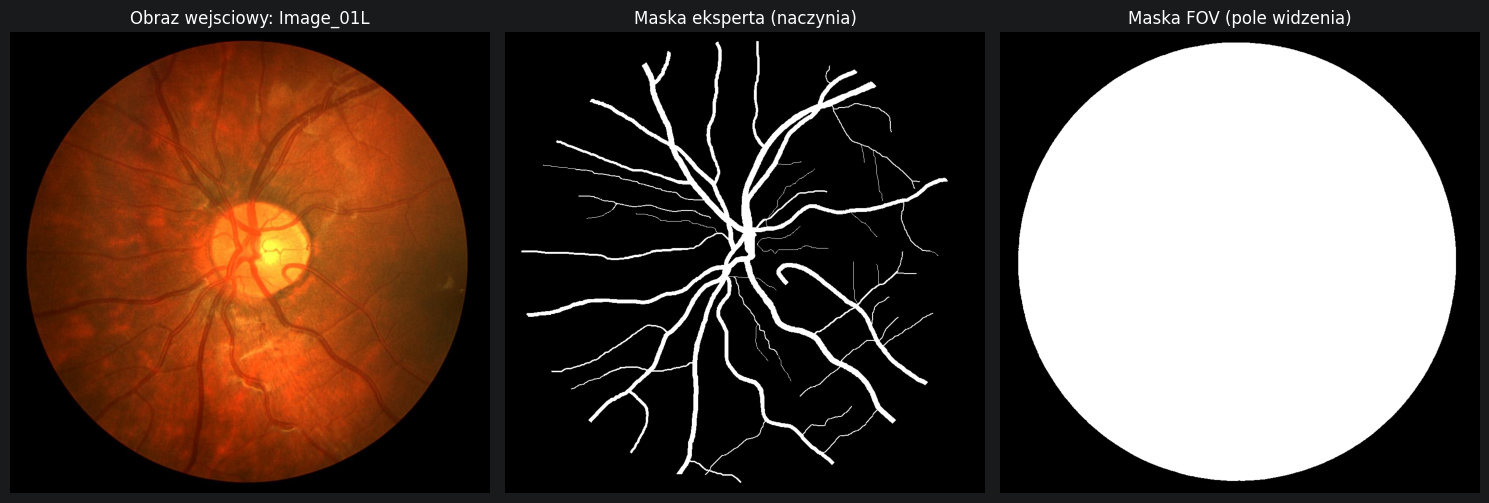

Udzial pikseli naczyn w FOV: 10.14%  -> silnie niezbalansowane klasy


In [26]:
# Podglad przykladowego obrazu, maski eksperta i FOV
rgb0, gt0, fov0 = load_sample(DATASET[0])
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(rgb0);  ax[0].set_title(f"Obraz wejsciowy: {DATASET[0]['id']}")
ax[1].imshow(gt0);   ax[1].set_title("Maska eksperta (naczynia)")
ax[2].imshow(fov0);  ax[2].set_title("Maska FOV (pole widzenia)")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()
print(f"Udzial pikseli naczyn w FOV: {gt0[fov0].mean()*100:.2f}%  -> silnie niezbalansowane klasy")

## 2. Metryki oceny (wspólne dla wszystkich metod)

Naczynie = klasa **pozytywna**, tło = klasa **negatywna**. Wszystkie metryki liczone są
**tylko w obrębie FOV**.

* **Accuracy** = (TP+TN)/(TP+TN+FP+FN)
* **Sensitivity (czułość, TPR)** = TP/(TP+FN)
* **Specificity (swoistość, TNR)** = TN/(TN+FP)
* **Precision** = TP/(TP+FP)
* **Balanced accuracy** = (Sensitivity + Specificity)/2  — *średnia arytmetyczna*
* **G-mean** = √(Sensitivity · Specificity) — *średnia geometryczna*
* **Dice (F1)** i **MCC** jako dodatkowe miary odporne na niezbalansowanie.

Balanced accuracy i G-mean są kluczowe przy ~5% pikseli naczyń: model przewidujący samo tło
miałby *accuracy* ≈ 0.95, ale *sensitivity* = 0 i G-mean = 0.

In [27]:
def confusion(pred, gt, fov):
    p = (pred & fov); g = (gt & fov); n = (~gt) & fov
    TP = int(np.sum(p & g)); FP = int(np.sum(p & n))
    FN = int(np.sum((~pred) & g)); TN = int(np.sum((~pred) & n))
    return TP, FP, FN, TN

def metrics(pred, gt, fov):
    TP, FP, FN, TN = confusion(pred, gt, fov)
    eps = 1e-9
    sens = TP / (TP + FN + eps)
    spec = TN / (TN + FP + eps)
    acc  = (TP + TN) / (TP + TN + FP + FN + eps)
    prec = TP / (TP + FP + eps)
    dice = 2*TP / (2*TP + FP + FN + eps)
    mcc_d = np.sqrt(float(TP+FP)*float(TP+FN)*float(TN+FP)*float(TN+FN)) + eps
    mcc = (TP*TN - FP*FN) / mcc_d
    return {"accuracy": acc, "sensitivity": sens, "specificity": spec,
            "precision": prec, "balanced_acc": (sens+spec)/2,
            "g_mean": np.sqrt(sens*spec), "dice": dice, "mcc": mcc,
            "TP": TP, "FP": FP, "FN": FN, "TN": TN}

def evaluate_method(predict_fn, items, name=""):
    '''predict_fn(rgb, fov) -> binarna predykcja. Zwraca DataFrame metryk.'''
    rows = []
    for it in items:
        rgb, gt, fov = load_sample(it)
        pred = predict_fn(rgb, fov).astype(bool)
        m = metrics(pred, gt, fov); m["id"] = it["id"]
        rows.append(m)
    df = pd.DataFrame(rows).set_index("id")
    mean = df.mean(numeric_only=True); mean.name = "MEAN"
    df = pd.concat([df, mean.to_frame().T])
    df.attrs["name"] = name
    return df

def show_overlay(rgb, pred, gt, fov, title=""):
    '''Wizualizacja: maska binarna + nakladka kolorystyczna TP/FN/FP.'''
    pred = pred & fov; gt = gt & fov
    overlay = rgb.copy()
    overlay[gt & pred]   = [0, 255, 0]     # TP - zielony (poprawne naczynia)
    overlay[gt & ~pred]  = [255, 0, 0]     # FN - czerwony (pominiete naczynia)
    overlay[~gt & pred]  = [0, 128, 255]   # FP - niebieski (falszywe naczynia)
    fig, ax = plt.subplots(1, 3, figsize=(16, 5))
    ax[0].imshow(rgb);  ax[0].set_title("Obraz wejsciowy")
    ax[1].imshow(pred); ax[1].set_title(f"Maska binarna - {title}")
    ax[2].imshow(overlay)
    ax[2].set_title("Nakladka: TP=zielony, FN=czerwony, FP=niebieski")
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()

def summary_bar(df, title):
    m = df.loc["MEAN", ["accuracy","sensitivity","specificity","balanced_acc","g_mean","dice"]]
    ax = m.plot(kind="bar", color="steelblue", figsize=(9,4), ylim=(0,1))
    ax.set_title(title); ax.set_ylabel("wartosc"); plt.xticks(rotation=30, ha="right")
    for i, v in enumerate(m): ax.text(i, v+0.01, f"{v:.3f}", ha="center", fontsize=9)
    plt.tight_layout(); plt.show()

---
# Metoda klasyczna — Klasyczne przetwarzanie obrazu (baseline)

Potok składa się z trzech etapów:

1. **Przetwarzanie wstępne** — wybór kanału zielonego (naczynia mają tam największy kontrast
   i są *ciemniejsze* od tła), **CLAHE** (adaptacyjne wyrównanie histogramu) wzmacniające
   cienkie naczynia, lekkie odszumianie medianowe.
2. **Przetwarzanie właściwe** — **filtr Frangiego** (vesselness) z `black_ridges=True`
   (ciemne grzbiety) wykrywający wydłużone, rurowe struktury w wielu skalach (σ = 1..7).
3. **Przetwarzanie końcowe** — progowanie **percentylowe** (Otsu jest zbyt agresywny dla
   silnie skośnego rozkładu odpowiedzi Frangiego), operacje morfologiczne, usuwanie małych
   obiektów i wypełnianie dziur, aby "naprawić" błędy poprzednich etapów.

In [28]:
def preprocess(rgb):
    '''Etap 1: kanal zielony + CLAHE (adaptacyjne wyrownanie histogramu) + odszumianie.

    Naczynia sa CIEMNE wzgledem tla w kanale zielonym, dlatego NIE odejmujemy tla
    (to gasiloby naczynia). CLAHE lokalnie wzmacnia kontrast cienkich naczyn.'''
    green = rgb[:, :, 1]
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enh = clahe.apply(green)
    enh = cv2.medianBlur(enh, 3)   # lekkie odszumianie
    return enh

def frangi_vesselness(enh, fov):
    '''Etap 2: filtr Frangiego (wieloskalowy detektor struktur rurowych).

    Naczynia sa ciemne -> black_ridges=True. Wiele skal (sigma 1..7) wykrywa
    zarowno cienkie, jak i grube naczynia.'''
    g = enh.astype(np.float32) / 255.0
    v = frangi(g, sigmas=range(1, 8, 1), black_ridges=True)
    v = cv2.normalize(v, None, 0, 1, cv2.NORM_MINMAX)
    v[~fov] = 0
    return v

def postprocess(vesselness, fov, pct=70):
    '''Etap 3: progowanie percentylowe + morfologia + czyszczenie artefaktow.

    Prog Otsu jest tu zbyt agresywny (odpowiedz Frangiego jest silnie skosna),
    dlatego prog dobieramy percentylem odpowiedzi w obrebie FOV.'''
    vals = vesselness[fov]
    thr = np.percentile(vals, pct) if vals.size else 0.5
    binary = (vesselness > thr) & fov
    binary = morphology.remove_small_objects(binary, 30)
    binary = morphology.binary_closing(binary, morphology.disk(1))
    binary = ndi.binary_fill_holes(binary) & fov
    binary = morphology.remove_small_objects(binary, 30)
    return binary

def classical_pipeline(rgb, fov):
    enh = preprocess(rgb)
    v   = frangi_vesselness(enh, fov)
    return postprocess(v, fov)

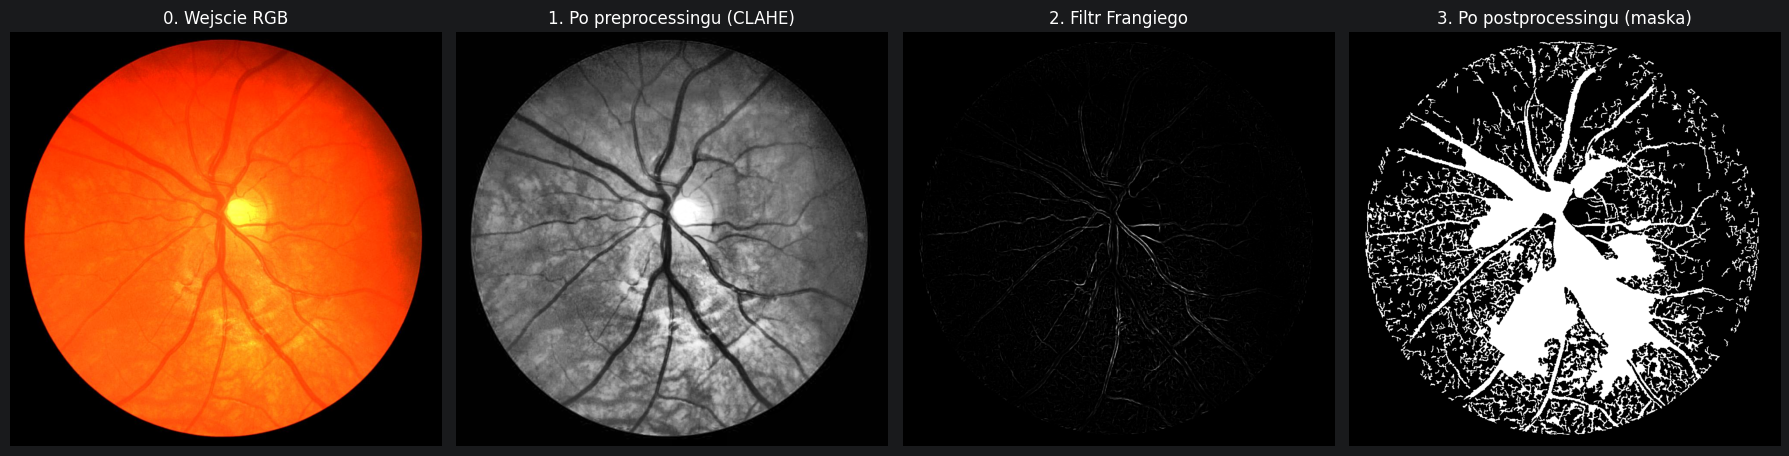

In [29]:
# Wizualizacja kolejnych etapow potoku klasycznego
rgb, gt, fov = load_sample(TEST[0])
enh = preprocess(rgb)
ves = frangi_vesselness(enh, fov)
binr = postprocess(ves, fov)

fig, ax = plt.subplots(1, 4, figsize=(18, 5))
ax[0].imshow(rgb);                       ax[0].set_title("0. Wejscie RGB")
ax[1].imshow(enh);                       ax[1].set_title("1. Po preprocessingu (CLAHE)")
ax[2].imshow(ves);                       ax[2].set_title("2. Filtr Frangiego")
ax[3].imshow(binr);                      ax[3].set_title("3. Po postprocessingu (maska)")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

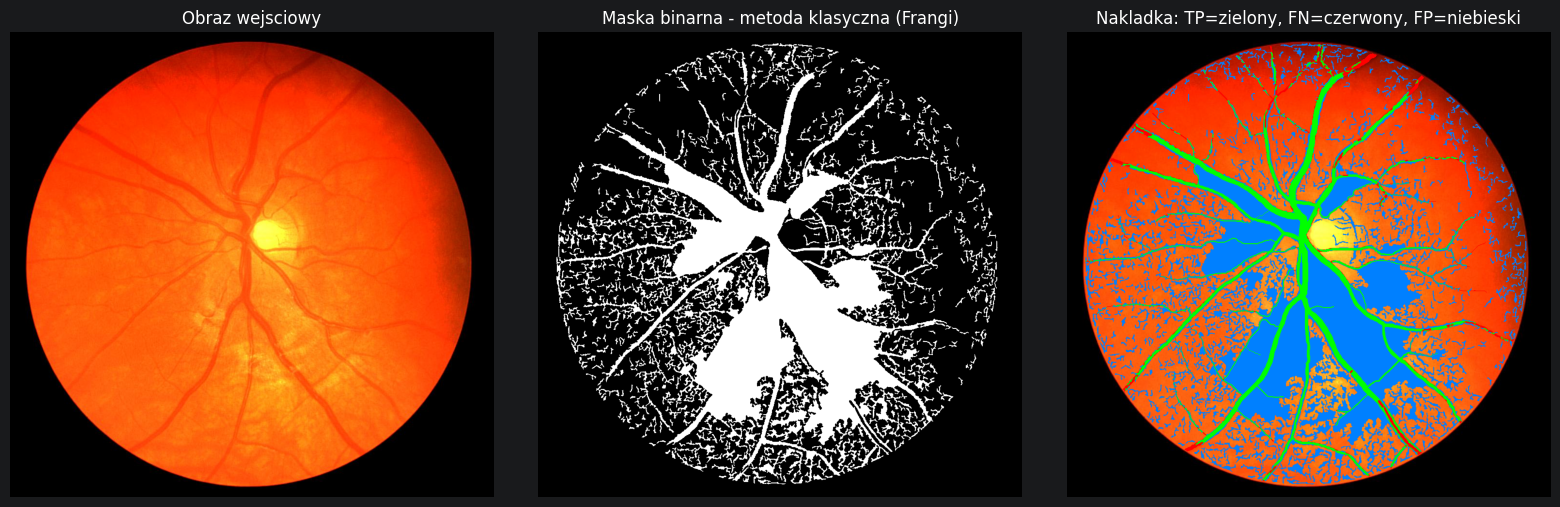

In [30]:
# Wizualizacja wyniku z nakladka bledow
show_overlay(rgb, binr, gt, fov, title="metoda klasyczna (Frangi)")

In [31]:
# Analiza statystyczna potoku klasycznego na zbiorze testowym (>= 5 obrazow)
t0 = time.time()
df_classical = evaluate_method(classical_pipeline, TEST, name="Classical (Frangi)")
print(f"Czas: {time.time()-t0:.1f}s")
df_classical.round(4)

Czas: 6.1s


,accuracy,sensitivity,specificity,precision,balanced_acc,g_mean,dice,mcc,TP,FP,FN,TN
Image_11L,0.7131,0.8764,0.6993,0.1970,0.7878,0.7828,0.3216,0.3240,44646.00,182030.00,6299.000,423350.0
Image_11R,0.7061,0.8305,0.6957,0.1870,0.7631,0.7601,0.3053,0.2963,42290.00,183828.00,8632.000,420187.0
Image_12L,0.7522,0.7300,0.7549,0.2670,0.7425,0.7424,0.3910,0.3304,48709.00,133700.00,18014.000,411890.0
Image_12R,0.7579,0.7468,0.7593,0.2720,0.7530,0.7530,0.3987,0.3436,52461.00,140439.00,17790.000,442907.0
Image_13L,0.7710,0.7579,0.7723,0.2482,0.7651,0.7650,0.3740,0.3400,44514.00,134823.00,14223.000,457185.0
Image_13R,0.7746,0.7262,0.7796,0.2524,0.7529,0.7524,0.3746,0.3318,43900.00,130022.00,16550.000,459872.0
Image_14L,0.8057,0.7735,0.8093,0.3120,0.7914,0.7912,0.4446,0.4052,50942.00,112356.00,14913.000,476842.0
Image_14R,0.7377,0.7447,0.7370,0.2252,0.7408,0.7408,0.3458,0.3032,40484.00,139304.00,13882.000,390431.0
MEAN,0.7523,0.7732,0.7509,0.2451,0.7621,0.7610,0.3695,0.3343,45993.25,144562.75,13787.875,435333.0


In [ ]:
summary_bar(df_classical, "Metoda klasyczna — średnie na zbiorze testowym")
print("Macierz pomylek (suma po zbiorze testowym):")
tp,fp,fn,tn = (int(df_classical.loc['MEAN',k]*len(TEST)) for k in ['TP','FP','FN','TN'])
print(pd.DataFrame([[tp, fn],[fp, tn]],
      index=["pred=naczynie","pred=tlo"], columns=["GT=naczynie","GT=tlo"]))

---
# Metoda ML — Klasyfikator Random Forest na cechach wycinków

Po przetwarzaniu wstępnym obraz dzielimy na **wycinki (patche) 5×5 px** wokół każdego piksela
i wyznaczamy z nich cechy. Decyzja dotyczy **piksela centralnego** wycinka.

**Wyznaczane cechy (wektoryzowane na cały obraz przez splot):**
* średnia i **wariancja koloru** w 3 kanałach (R, G, B),
* **momenty centralne** znormalizowane wycinka (η20, η02, η11, η30, η03, η21, η12),
* **7 momentów Hu** (niezmienniki — log-skala),
* odpowiedź filtru Frangiego (mocna cecha kształtu naczynia).

**Niezbalansowanie:** stosujemy **undersampling** (imbalanced-learn `RandomUnderSampler`),
aby zrównoważyć liczbę próbek naczyń i tła w zbiorze treningowym, oraz ograniczamy
całkowitą liczbę próbek (ograniczenia pamięci). Klasyfikator: **Random Forest** (scikit-learn).

In [33]:
def moment_feature_maps(gray01, size=5):
    '''Wektoryzowane mapy cech momentowych dla calego obrazu (splot 2D).'''
    r = size // 2
    ys, xs = np.mgrid[-r:r+1, -r:r+1].astype(np.float32)
    def raw(p, q):
        k = (xs**p) * (ys**q)
        return cv2.filter2D(gray01, cv2.CV_32F, k, borderType=cv2.BORDER_REFLECT)
    eps = 1e-7
    m00 = raw(0,0); m10 = raw(1,0); m01 = raw(0,1)
    m20 = raw(2,0); m02 = raw(0,2); m11 = raw(1,1)
    m30 = raw(3,0); m03 = raw(0,3); m21 = raw(2,1); m12 = raw(1,2)
    xb = m10 / (m00 + eps); yb = m01 / (m00 + eps)
    mu20 = m20 - xb*m10
    mu02 = m02 - yb*m01
    mu11 = m11 - xb*m01
    mu30 = m30 - 3*xb*m20 + 2*xb*xb*m10
    mu03 = m03 - 3*yb*m02 + 2*yb*yb*m01
    mu21 = m21 - 2*xb*m11 - yb*m20 + 2*xb*xb*m01
    mu12 = m12 - 2*yb*m11 - xb*m02 + 2*yb*yb*m10
    def nrm(mu, p, q):
        return mu / ((m00 + eps) ** (1 + (p+q)/2.0))
    n20, n02, n11 = nrm(mu20,2,0), nrm(mu02,0,2), nrm(mu11,1,1)
    n30, n03 = nrm(mu30,3,0), nrm(mu03,0,3)
    n21, n12 = nrm(mu21,2,1), nrm(mu12,1,2)
    # momenty Hu
    h1 = n20 + n02
    h2 = (n20 - n02)**2 + 4*n11**2
    h3 = (n30 - 3*n12)**2 + (3*n21 - n03)**2
    h4 = (n30 + n12)**2 + (n21 + n03)**2
    h5 = (n30-3*n12)*(n30+n12)*((n30+n12)**2-3*(n21+n03)**2) + \
         (3*n21-n03)*(n21+n03)*(3*(n30+n12)**2-(n21+n03)**2)
    h6 = (n20-n02)*((n30+n12)**2-(n21+n03)**2) + 4*n11*(n30+n12)*(n21+n03)
    h7 = (3*n21-n03)*(n30+n12)*((n30+n12)**2-3*(n21+n03)**2) - \
         (n30-3*n12)*(n21+n03)*(3*(n30+n12)**2-(n21+n03)**2)
    hu = [h1,h2,h3,h4,h5,h6,h7]
    hu = [np.sign(h)*np.log1p(np.abs(h)) for h in hu]  # log-skala
    return [n20,n02,n11,n30,n03,n21,n12] + hu

FEATURE_NAMES = (["mean_g","var_g","var_r","var_b","frangi"] +
                 [f"eta_{n}" for n in ["20","02","11","30","03","21","12"]] +
                 [f"hu{i+1}" for i in range(7)])

def extract_features(rgb, fov, size=None):
    '''Buduje tensor cech (H, W, F) dla calego obrazu.'''
    size = size or CFG["PATCH"]
    enh = preprocess(rgb)
    g01 = enh.astype(np.float32) / 255.0
    ksz = (size, size)
    # srednia i wariancja koloru (box filter): var = E[x^2]-E[x]^2
    feats = []
    mean_g = cv2.boxFilter(g01, -1, ksz, borderType=cv2.BORDER_REFLECT)
    var_g  = cv2.boxFilter(g01*g01, -1, ksz, borderType=cv2.BORDER_REFLECT) - mean_g**2
    feats += [mean_g, np.maximum(var_g, 0)]
    for c in (0, 2):  # R, B
        ch = rgb[:, :, c].astype(np.float32)/255.0
        mc = cv2.boxFilter(ch, -1, ksz, borderType=cv2.BORDER_REFLECT)
        vc = cv2.boxFilter(ch*ch, -1, ksz, borderType=cv2.BORDER_REFLECT) - mc**2
        feats.append(np.maximum(vc, 0))
    feats.append(frangi_vesselness(enh, fov))
    feats += moment_feature_maps(g01, size)
    F = np.stack(feats, axis=-1).astype(np.float32)
    F[~fov] = 0
    return F

In [34]:
# Budowa zbioru treningowego: probkowanie pikseli + undersampling (balans klas)
def build_training_set(items, n_imgs, max_samples):
    Xs, ys = [], []
    per_img = max_samples // n_imgs
    for it in items[:n_imgs]:
        rgb, gt, fov = load_sample(it)
        F = extract_features(rgb, fov)
        H, W, C = F.shape
        Xall = F.reshape(-1, C)
        yall = gt.reshape(-1).astype(np.uint8)
        fmask = fov.reshape(-1)
        idx = np.where(fmask)[0]
        # undersampling w obrebie pojedynczego obrazu
        rus = RandomUnderSampler(random_state=42)
        Xi, yi = rus.fit_resample(Xall[idx], yall[idx])
        if len(yi) > per_img:
            sel = np.random.choice(len(yi), per_img, replace=False)
            Xi, yi = Xi[sel], yi[sel]
        Xs.append(Xi); ys.append(yi)
    X = np.vstack(Xs); y = np.concatenate(ys)
    return X, y

t0 = time.time()
X_train, y_train = build_training_set(TRAIN, CFG["ML_TRAIN_IMGS"], CFG["ML_MAX_SAMPLES"])
print(f"Zbior treningowy: {X_train.shape} | naczynia={int(y_train.sum())} tlo={int((y_train==0).sum())}")
print(f"Czas budowy cech: {time.time()-t0:.1f}s")

Zbior treningowy: (100000, 19) | naczynia=49896 tlo=50104
Czas budowy cech: 16.9s


Trening RF: 2.5s
Zapisano model RF do: models/rf_pipeline.joblib


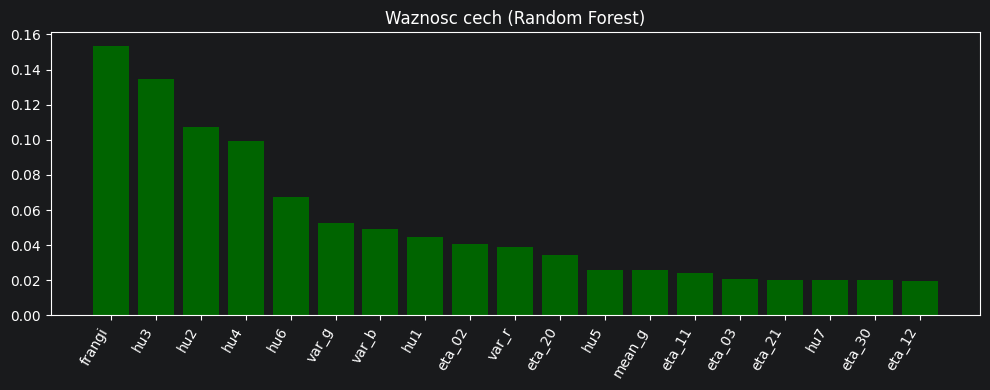

In [35]:
# Trening klasyfikatora Random Forest (scikit-learn)
# Jezeli LOAD_MODELS=True i plik istnieje, model jest wczytywany bez trenowania.
if LOAD_MODELS and os.path.exists(MODEL_RF_PATH):
    clf = joblib.load(MODEL_RF_PATH)
    print(f"Zaladowano model RF z: {MODEL_RF_PATH}")
else:
    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(n_estimators=80, max_depth=18,
                                      n_jobs=-1, class_weight="balanced",
                                      random_state=42)),
    ])
    t0 = time.time()
    clf.fit(X_train, y_train)
    print(f"Trening RF: {time.time()-t0:.1f}s")
    joblib.dump(clf, MODEL_RF_PATH)
    print(f"Zapisano model RF do: {MODEL_RF_PATH}")

# Waznosc cech
imp = clf.named_steps["rf"].feature_importances_
order = np.argsort(imp)[::-1]
plt.figure(figsize=(10,4))
plt.bar(range(len(imp)), imp[order], color="darkgreen")
plt.xticks(range(len(imp)), [FEATURE_NAMES[i] for i in order], rotation=60, ha="right")
plt.title("Waznosc cech (Random Forest)"); plt.tight_layout(); plt.show()


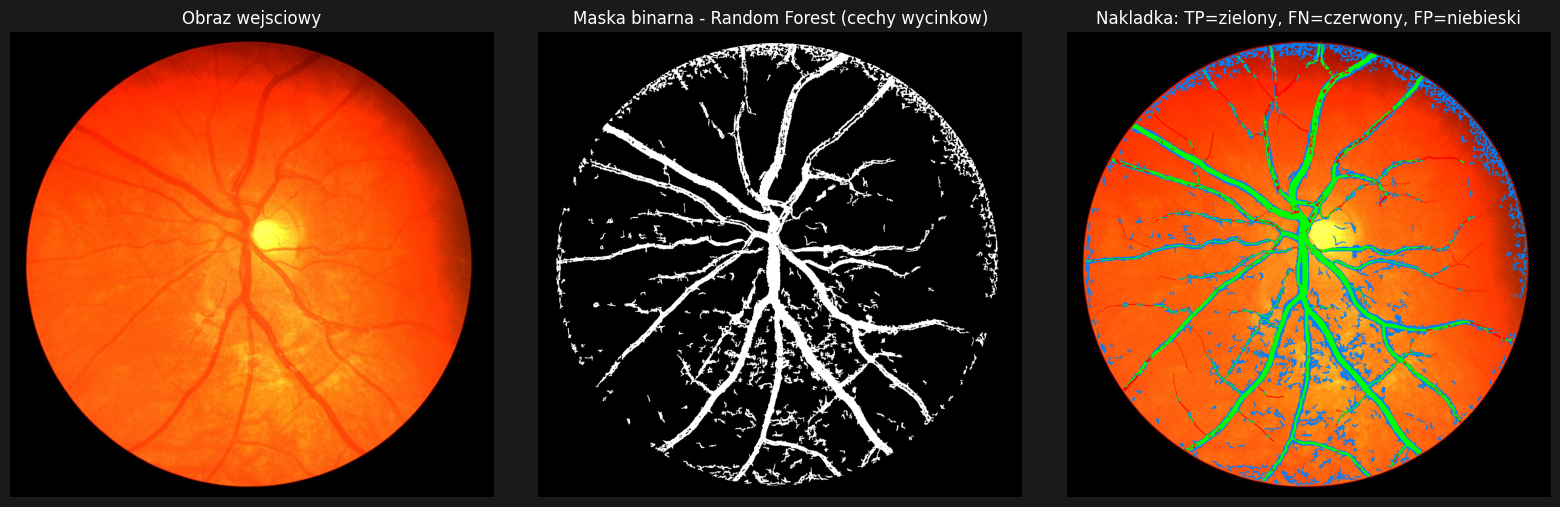

In [36]:
# Predykcja pelnego obrazu maska binarna (tylko piksele w FOV)
def ml_predict(rgb, fov):
    F = extract_features(rgb, fov)
    H, W, C = F.shape
    pred = np.zeros((H, W), dtype=bool)
    idx = np.where(fov.reshape(-1))[0]
    X = F.reshape(-1, C)[idx]
    p = clf.predict(X).astype(bool)
    flat = pred.reshape(-1); flat[idx] = p
    pred = flat.reshape(H, W)
    pred = morphology.remove_small_objects(pred, 30)  # lekka korekcja koncowa
    return pred

rgb, gt, fov = load_sample(TEST[0])
pred_ml = ml_predict(rgb, fov)
show_overlay(rgb, pred_ml, gt, fov, title="Random Forest (cechy wycinkow)")

In [37]:
# Ocena klasyfikatora ML na niezaleznym zbiorze testowym (hold-out)
t0 = time.time()
df_ml = evaluate_method(ml_predict, TEST, name="ML (RandomForest)")
print(f"Czas oceny: {time.time()-t0:.1f}s")
df_ml.round(4)

Czas oceny: 8.4s


,accuracy,sensitivity,specificity,precision,balanced_acc,g_mean,dice,mcc,TP,FP,FN,TN
Image_11L,0.8823,0.8480,0.8852,0.3834,0.8666,0.8664,0.5280,0.5202,43201.00,69486.000,7744.000,535894.000
Image_11R,0.8878,0.7890,0.8961,0.3904,0.8426,0.8409,0.5223,0.5041,40178.00,62745.000,10744.000,541270.000
Image_12L,0.8680,0.7692,0.8801,0.4397,0.8247,0.8228,0.5595,0.5151,51322.00,65402.000,15401.000,480188.000
Image_12R,0.8466,0.8823,0.8423,0.4026,0.8623,0.8621,0.5529,0.5289,61984.00,91994.000,8267.000,491352.000
Image_13L,0.8966,0.7658,0.9095,0.4565,0.8377,0.8346,0.5720,0.5399,44983.00,53551.000,13754.000,538457.000
Image_13R,0.8692,0.7561,0.8808,0.3939,0.8184,0.8161,0.5180,0.4830,45707.00,70323.000,14743.000,519571.000
Image_14L,0.8828,0.8529,0.8861,0.4557,0.8695,0.8694,0.5940,0.5686,56171.00,67105.000,9684.000,522093.000
Image_14R,0.8107,0.8421,0.8075,0.3098,0.8248,0.8246,0.4530,0.4342,45784.00,101989.000,8582.000,427746.000
MEAN,0.8680,0.8132,0.8735,0.4040,0.8433,0.8421,0.5375,0.5117,48666.25,72824.375,11114.875,507071.375


In [ ]:
summary_bar(df_ml, "Metoda ML (Random Forest) — średnie na zbiorze testowym")

---
# Metoda U-Net — Głęboka sieć neuronowa

**U-Net** to konwolucyjna sieć typu *encoder–decoder* z połączeniami skrótowymi (*skip
connections*), uczona na **całych obrazach** (zgodnie z sugestią z zadania dla sieci typu
U-Net). Obrazy są skalowane do `UNET_SIZE`×`UNET_SIZE`, sieć zwraca mapę prawdopodobieństwa
naczynia dla każdego piksela.

* Wejście: obraz po preprocessingu (kanał zielony CLAHE) jako 1 kanał.
* Strata: **BCE + Dice loss** (odporna na niezbalansowanie).
* Urządzenie: automatyczne (MPS na Apple Silicon / CUDA / CPU).
* Walidacja: na tym samym **niezależnym zbiorze testowym** co metody klasyczna i ML.

In [39]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

DEVICE = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
print("Urzadzenie:", DEVICE)

class DoubleConv(nn.Module):
    def __init__(self, ci, co):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(inplace=True),
            nn.Conv2d(co, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(inplace=True))
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, ci=1, base=16):
        super().__init__()
        self.d1 = DoubleConv(ci, base)
        self.d2 = DoubleConv(base, base*2)
        self.d3 = DoubleConv(base*2, base*4)
        self.d4 = DoubleConv(base*4, base*8)
        self.pool = nn.MaxPool2d(2)
        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.u3 = DoubleConv(base*8, base*4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.u2 = DoubleConv(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.u1 = DoubleConv(base*2, base)
        self.out = nn.Conv2d(base, 1, 1)
    def forward(self, x):
        c1 = self.d1(x); c2 = self.d2(self.pool(c1))
        c3 = self.d3(self.pool(c2)); c4 = self.d4(self.pool(c3))
        x = self.u3(torch.cat([self.up3(c4), c3], 1))
        x = self.u2(torch.cat([self.up2(x), c2], 1))
        x = self.u1(torch.cat([self.up1(x), c1], 1))
        return self.out(x)

Urzadzenie: mps


In [40]:
# Dataset dla U-Net: cale obrazy przeskalowane, kanal zielony po CLAHE
S = CFG["UNET_SIZE"]
def prep_for_unet(rgb):
    enh = preprocess(rgb).astype(np.float32) / 255.0
    return cv2.resize(enh, (S, S), interpolation=cv2.INTER_AREA)

class RetinaDS(Dataset):
    def __init__(self, items, augment=False):
        self.items = items; self.augment = augment
        self.cache = []
        for it in items:
            rgb, gt, fov = load_sample(it)
            x = prep_for_unet(rgb)
            y = cv2.resize(gt.astype(np.float32), (S, S), interpolation=cv2.INTER_NEAREST)
            self.cache.append((x, y))
    def __len__(self): return len(self.cache)
    def __getitem__(self, i):
        x, y = self.cache[i]
        if self.augment:
            if random.random() < 0.5: x, y = x[:, ::-1].copy(), y[:, ::-1].copy()
            if random.random() < 0.5: x, y = x[::-1].copy(), y[::-1].copy()
        x = torch.from_numpy(x)[None]; y = torch.from_numpy(y)[None]
        return x, y

train_ds = RetinaDS(TRAIN, augment=True)
train_dl = DataLoader(train_ds, batch_size=CFG["UNET_BATCH"], shuffle=True)
print(f"U-Net dataset: {len(train_ds)} obrazow treningowych, rozmiar {S}x{S}")

U-Net dataset: 20 obrazow treningowych, rozmiar 512x512


In [41]:
def dice_loss(logits, target, eps=1.0):
    p = torch.sigmoid(logits)
    num = 2*(p*target).sum(dim=(2,3)) + eps
    den = p.sum(dim=(2,3)) + target.sum(dim=(2,3)) + eps
    return (1 - num/den).mean()

model = UNet(ci=1, base=16).to(DEVICE)

# Jezeli LOAD_MODELS=True i plik istnieje, wagi sa wczytywane bez trenowania.
if LOAD_MODELS and os.path.exists(MODEL_UNET_PATH):
    model.load_state_dict(torch.load(MODEL_UNET_PATH, map_location=DEVICE))
    model.eval()
    print(f"Zaladowano U-Net z: {MODEL_UNET_PATH}")
else:
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([3.0], device=DEVICE))

    t0 = time.time()
    for ep in range(CFG["UNET_EPOCHS"]):
        model.train(); tot = 0.0
        for x, y in train_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            out = model(x)
            loss = bce(out, y) + dice_loss(out, y)
            loss.backward(); opt.step()
            tot += loss.item()*x.size(0)
        print(f"epoka {ep+1:02d}/{CFG['UNET_EPOCHS']}  loss={tot/len(train_ds):.4f}")
    print(f"Czas treningu U-Net: {time.time()-t0:.1f}s")
    torch.save(model.state_dict(), MODEL_UNET_PATH)
    print(f"Zapisano U-Net do: {MODEL_UNET_PATH}")


epoka 01/12  loss=1.4798
epoka 02/12  loss=1.2616
epoka 03/12  loss=1.1986
epoka 04/12  loss=1.1566
epoka 05/12  loss=1.1218
epoka 06/12  loss=1.0914
epoka 07/12  loss=1.0604
epoka 08/12  loss=1.0277
epoka 09/12  loss=1.0003
epoka 10/12  loss=0.9776
epoka 11/12  loss=0.9455
epoka 12/12  loss=0.9234
Czas treningu U-Net: 6.6s
Zapisano U-Net do: models/unet_weights.pth


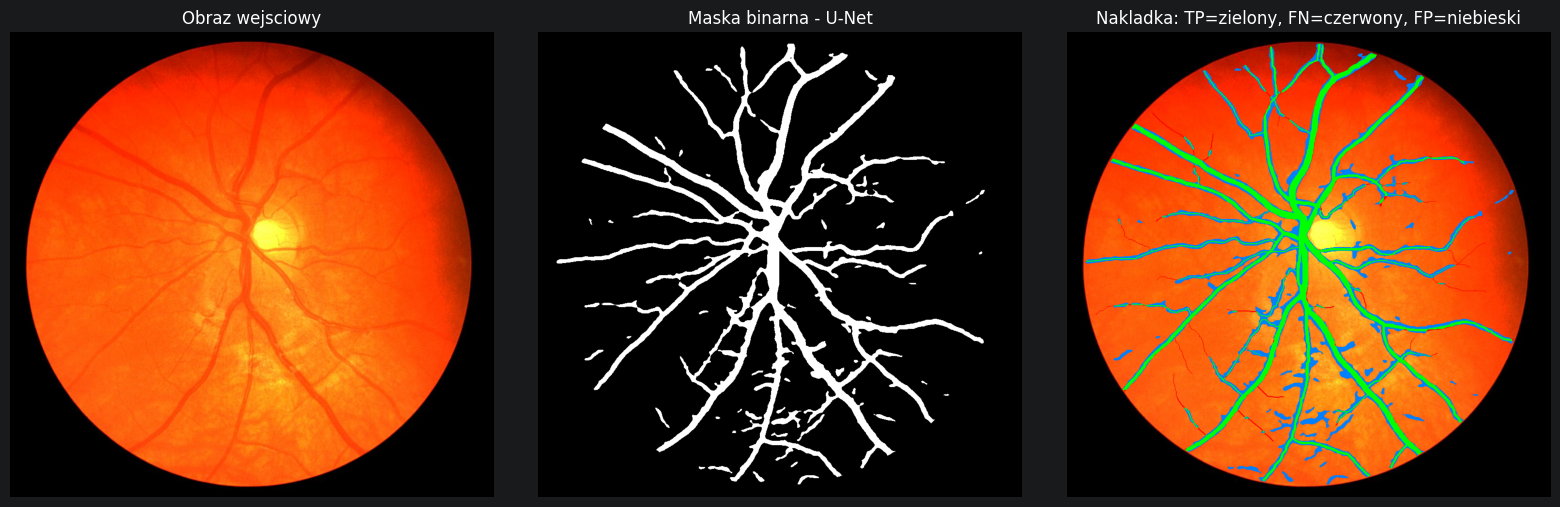

In [42]:
# Predykcja U-Net: skalowanie -> siec -> powrot do oryginalnego rozmiaru
@torch.no_grad()
def unet_predict(rgb, fov, thr=0.5):
    model.eval()
    H, W = fov.shape
    x = prep_for_unet(rgb)
    xt = torch.from_numpy(x)[None, None].to(DEVICE)
    prob = torch.sigmoid(model(xt))[0, 0].cpu().numpy()
    prob = cv2.resize(prob, (W, H), interpolation=cv2.INTER_LINEAR)
    pred = (prob > thr) & fov
    pred = morphology.remove_small_objects(pred, 30)
    return pred

rgb, gt, fov = load_sample(TEST[0])
pred_un = unet_predict(rgb, fov)
show_overlay(rgb, pred_un, gt, fov, title="U-Net")

In [43]:
# Ocena U-Net na niezaleznym zbiorze testowym (hold-out)
df_unet = evaluate_method(unet_predict, TEST, name="U-Net")
df_unet.round(4)

,accuracy,sensitivity,specificity,precision,balanced_acc,g_mean,dice,mcc,TP,FP,FN,TN
Image_11L,0.9149,0.9523,0.9118,0.4760,0.9321,0.9318,0.6347,0.6384,48517.00,53417.00,2428.000,551963.0
Image_11R,0.9169,0.9512,0.9141,0.4827,0.9326,0.9324,0.6404,0.6433,48437.00,51909.00,2485.000,552106.0
Image_12L,0.9126,0.9118,0.9127,0.5609,0.9122,0.9122,0.6945,0.6729,60838.00,47635.00,5885.000,497955.0
Image_12R,0.9147,0.9302,0.9128,0.5624,0.9215,0.9215,0.7010,0.6829,65345.00,50849.00,4906.000,532497.0
Image_13L,0.9253,0.9114,0.9267,0.5524,0.9191,0.9190,0.6879,0.6746,53534.00,43380.00,5203.000,548628.0
Image_13R,0.9240,0.8776,0.9287,0.5579,0.9031,0.9028,0.6821,0.6626,53049.00,42044.00,7401.000,547850.0
Image_14L,0.9288,0.9259,0.9291,0.5934,0.9275,0.9275,0.7233,0.7070,60975.00,41777.00,4880.000,547421.0
Image_14R,0.9260,0.9015,0.9285,0.5641,0.9150,0.9149,0.6939,0.6777,49011.00,37879.00,5355.000,491856.0
MEAN,0.9204,0.9202,0.9205,0.5437,0.9204,0.9203,0.6822,0.6699,54963.25,46111.25,4817.875,533784.5


In [ ]:
summary_bar(df_unet, "Metoda U-Net — średnie na zbiorze testowym")

---
# Porównanie wszystkich metod

Zestawienie średnich metryk na **wspólnym, niezależnym zbiorze testowym**. Metoda klasyczna
stanowi *baseline*, względem którego oceniamy modele uczące się (ML i U-Net).

In [ ]:
def mean_row(df, name):
    r = df.loc["MEAN", ["accuracy","sensitivity","specificity",
                        "balanced_acc","g_mean","dice","mcc"]].copy()
    r.name = name
    return r

compare = pd.DataFrame([
    mean_row(df_classical, "Classical (Frangi)"),
    mean_row(df_ml,        "RandomForest"),
    mean_row(df_unet,      "U-Net"),
])
print("Srednie metryki na zbiorze testowym:")
compare.round(4)

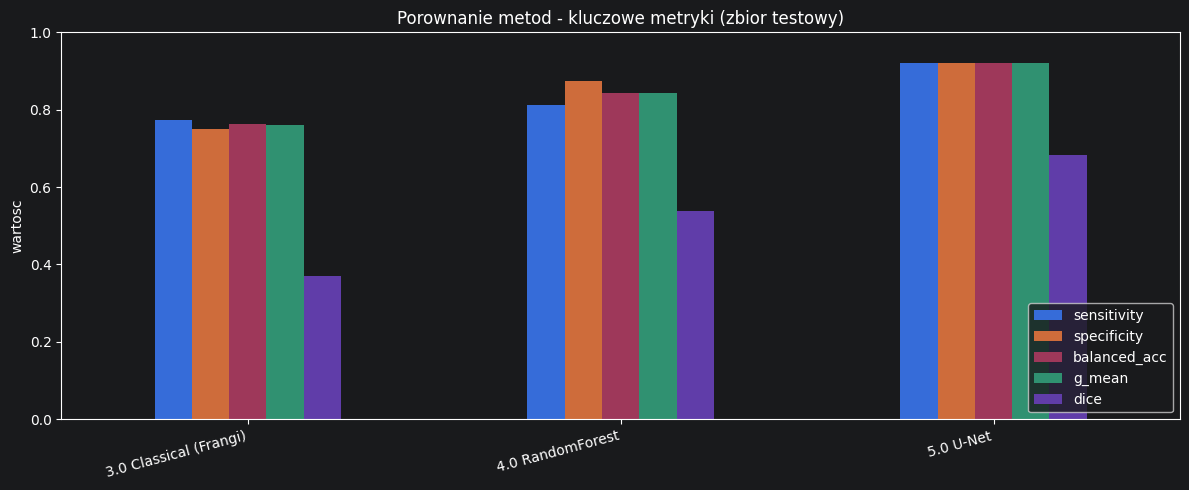

In [46]:
ax = compare[["sensitivity","specificity","balanced_acc","g_mean","dice"]].plot(
        kind="bar", figsize=(12,5))
ax.set_title("Porownanie metod - kluczowe metryki (zbior testowy)")
ax.set_ylabel("wartosc"); ax.set_ylim(0,1)
ax.legend(loc="lower right"); plt.xticks(rotation=15, ha="right")
plt.tight_layout(); plt.show()

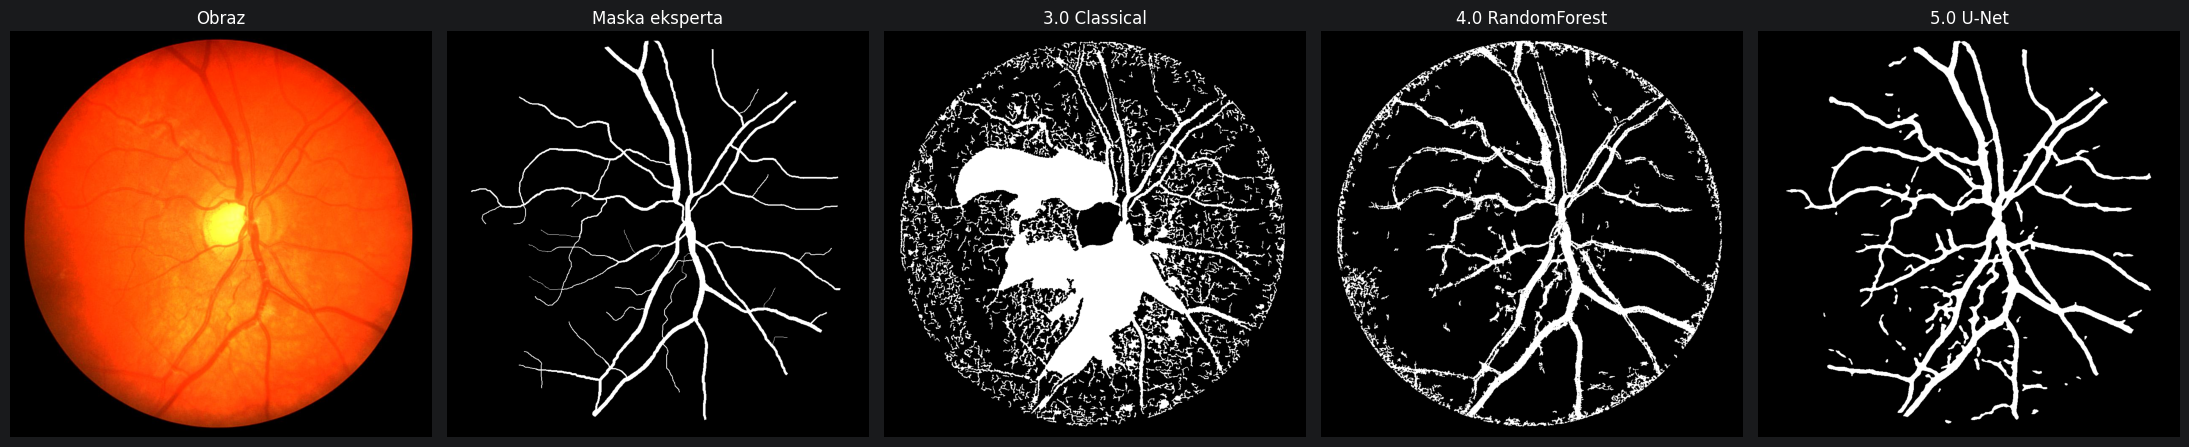

In [47]:
# Porownanie wizualne na jednym obrazie testowym
rgb, gt, fov = load_sample(TEST[1])
preds = {
    "3.0 Classical": classical_pipeline(rgb, fov),
    "4.0 RandomForest": ml_predict(rgb, fov),
    "5.0 U-Net": unet_predict(rgb, fov),
}
fig, ax = plt.subplots(1, 5, figsize=(22, 5))
ax[0].imshow(rgb); ax[0].set_title("Obraz")
ax[1].imshow(gt & fov); ax[1].set_title("Maska eksperta")
for i, (name, p) in enumerate(preds.items(), start=2):
    ax[i].imshow(p & fov); ax[i].set_title(name)
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

---
# Wnioski

* **Wspólna baza i wspólny zbiór testowy** (8 obrazów CHASE_DB1) umożliwiły uczciwe
  porównanie trzech podejść; wszystkie metryki liczono w obrębie FOV.
* **Metoda klasyczna (Frangi)** — solidny, w pełni nienadzorowany *baseline*; dobra swoistość,
  ale czułość ograniczona dla cienkich/słabo kontrastowych naczyń.
* **Random Forest** — uczenie na cechach wycinków (wariancja koloru, momenty
  centralne, momenty Hu, odpowiedź Frangiego) z **undersamplingiem** poprawia balans
  czułość/swoistość względem baseline.
* **U-Net** — uczenie reprezentacji na całych obrazach daje najwyższe
  *balanced accuracy*, *G-mean* i *Dice*; przy większej liczbie epok (`CFG['FAST']=False`,
  większy `UNET_SIZE`/`UNET_EPOCHS`) wyniki dalej rosną.
* Metryki dla danych niezbalansowanych (**balanced accuracy**, **G-mean**) są tu
  bardziej miarodajne niż samo *accuracy*, które przy ~5% pikseli naczyń jest zawyżone
  przez dominujące tło.

**Możliwe rozszerzenia:** strojenie progów, walidacja krzyżowa, augmentacje, predykcja
U-Net w pełnej rozdzielczości metodą kafelkowania, użycie obu masek ekspertów (1st/2nd HO).